# Chapter 2 Learning File

## Pulling German Credit Data

In [18]:
import os
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb



## Colour Palette Selection

In [ ]:
# ── Colour Palette ────────────────────────────────────────────────
palette = {
    'primary':     '#2E75B6',   # blue — main bars, lines
    'secondary':   '#1F4E79',   # dark blue — headers, emphasis
    'accent':      '#70AD47',   # green — positive / no default
    'warning':     '#ED7D31',   # orange — caution / watch
    'danger':      '#C00000',   # red — default / high risk
    'neutral':     '#7F7F7F',   # grey — secondary info
    'light':       '#DEEAF1',   # pale blue — backgrounds, fills
    'white':       '#FFFFFF',
    'text':        '#262626',   # near black — axis labels
}

# ── Chart Defaults ────────────────────────────────────────────────

plt.rcParams['figure.figsize']    = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelcolor']   = palette['text']
plt.rcParams['xtick.color']       = palette['text']
plt.rcParams['ytick.color']       = palette['text']
plt.rcParams['font.family']       = 'Arial'

In [19]:
columns = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installments', 'housing',
    'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'target'
]


In [20]:
# Build path relative to notebook location
base_path = os.path.dirname(os.path.abspath('exploration.ipynb'))
data_path = os.path.join(base_path, 'German Credit Data', 'german.data')

# Load data
df = pd.read_csv('../German Credit Data/german.data', sep=' ', header=None, names=columns)

## Exploration based on study guide

### Continuous Data

Numerical data that can take any value within a range, including decimals. There is no meaningful gap between possible values. In credit risk: income ($67,432.50), loan amount, interest rate, LVR. These variables are modelled differently from counts or categories.

In [21]:
print(df.select_dtypes(include='number').describe().round(2))

       duration  credit_amount  installment_rate  residence_since      age  \
count   1000.00        1000.00           1000.00          1000.00  1000.00   
mean      20.90        3271.26              2.97             2.84    35.55   
std       12.06        2822.74              1.12             1.10    11.38   
min        4.00         250.00              1.00             1.00    19.00   
25%       12.00        1365.50              2.00             2.00    27.00   
50%       18.00        2319.50              3.00             3.00    33.00   
75%       24.00        3972.25              4.00             4.00    42.00   
max       72.00       18424.00              4.00             4.00    75.00   

       existing_credits  dependents   target  
count           1000.00     1000.00  1000.00  
mean               1.41        1.16     1.30  
std                0.58        0.36     0.46  
min                1.00        1.00     1.00  
25%                1.00        1.00     1.00  
50%            

In [22]:

print(df.select_dtypes(include='string').describe().round(2))

print(df['checking_status'].value_counts().sort_index())


       checking_status credit_history purpose savings employment  \
count             1000           1000    1000    1000       1000   
unique               4              5      10       5          5   
top                A14            A32     A43     A61        A73   
freq               394            530     280     603        339   

       personal_status other_debtors property other_installments housing  \
count             1000          1000     1000               1000    1000   
unique               4             3        4                  3       3   
top                A93          A101     A123               A143    A152   
freq               548           907      332                814     713   

         job telephone foreign_worker  
count   1000      1000           1000  
unique     4         2              2  
top     A173      A191           A201  
freq     630       596            963  
checking_status
A11    274
A12    269
A13     63
A14    394
Name: count, dtype

### Mapping and plotting

In [23]:
# Mapping checking status categories

checking_status_map = {
    'A11': "Less than zero DM",
    'A12': "Zero to 200 DM",
    'A13': 'Greater than 200 DM',
    'A14': 'No Checking Account'
}

df['checking_status'] = df['checking_status'].map(checking_status_map)

print(df['checking_status'].value_counts())

checking_status
No Checking Account    394
Less than zero DM      274
Zero to 200 DM         269
Greater than 200 DM     63
Name: count, dtype: int64


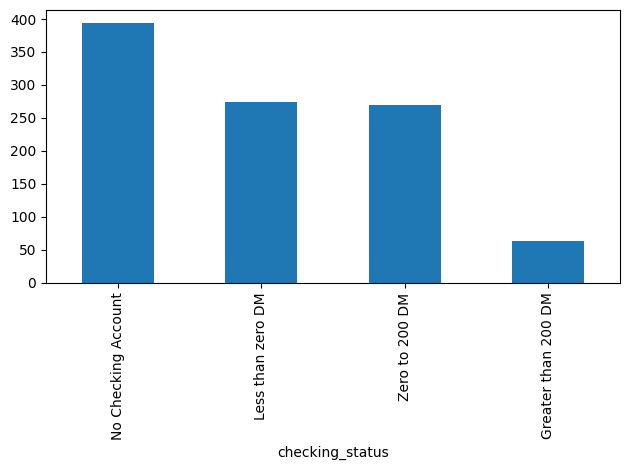

In [25]:

df['checking_status'].value_counts().plot(kind='bar')

plt.tight_layout()
plt.show()